In [33]:
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Documents\Airline_Delays_Cleaned_Dataset.csv")

print(df.head())


   Flight_ID   Airline  Distance_km  Departure_Delay_min  Arrival_Delay_min  \
0          1    Indigo         7609                    4                155   
1          2  Emirates        11735                  148                 65   
2          3     Delta         3555                  176                 72   
3          4    Indigo         7539                   25                154   
4          5  Emirates        11483                  150                 76   

  Delay_Status  Delay_Difference Distance_Category Performance_Label  
0      Delayed               151         Long Haul              Poor  
1      Delayed               -83         Long Haul              Poor  
2      Delayed              -104       Medium Long              Poor  
3       OnTime               129         Long Haul              Poor  
4       OnTime               -74         Long Haul              Poor  


In [35]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Flight_ID            15000 non-null  int64 
 1   Airline              15000 non-null  object
 2   Distance_km          15000 non-null  int64 
 3   Departure_Delay_min  15000 non-null  int64 
 4   Arrival_Delay_min    15000 non-null  int64 
 5   Delay_Status         15000 non-null  object
 6   Delay_Difference     15000 non-null  int64 
 7   Distance_Category    15000 non-null  object
 8   Performance_Label    15000 non-null  object
dtypes: int64(5), object(4)
memory usage: 1.0+ MB


,Flight_ID,Distance_km,Departure_Delay_min,Arrival_Delay_min,Delay_Difference
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,6131.577733,89.526000,99.412333,9.886333
std,4330.271354,3400.733506,51.988534,57.721229,77.443907
min,1.000000,201.000000,0.000000,0.000000,-177.000000
25%,3750.750000,3155.000000,44.000000,50.000000,-46.000000
50%,7500.500000,6141.000000,90.000000,99.000000,10.000000
75%,11250.250000,9090.250000,135.000000,149.000000,65.000000
max,15000.000000,11999.000000,179.000000,199.000000,197.000000


In [ ]:
==Which Airline Performs Better?

In [53]:
df.groupby("Airline")["Arrival_Delay_min"].mean().sort_values()


Airline
Lufthansa     97.896449
Indigo        99.635575
Emirates      99.887500
Delta        100.190589
Name: Arrival_Delay_min, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

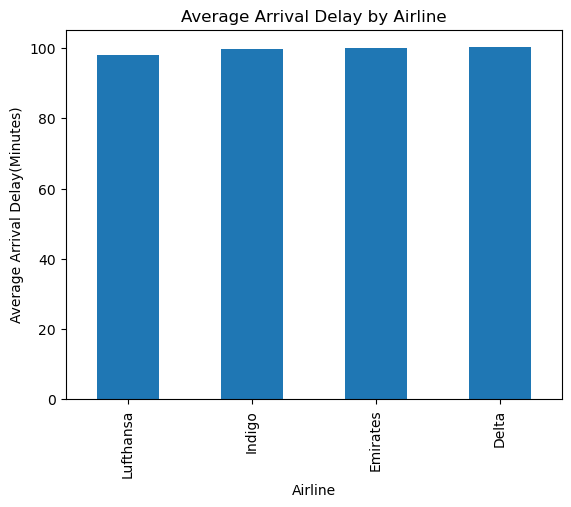

In [74]:
import matplotlib.pyplot as plt

df.groupby("Airline")["Arrival_Delay_min"].mean().sort_values().plot(kind="bar")

plt.title("Average Arrival Delay by Airline")
plt.ylabel("Airline")
plt.ylabel("Average Arrival Delay(Minutes)")

plt.show


In [ ]:
----Which Airline Struggle With Punctuality

In [78]:
df[df["Delay_Status"]=="Delayed"]["Airline"].value_counts()

Airline
Emirates     1968
Indigo       1897
Delta        1878
Lufthansa    1852
Name: count, dtype: int64

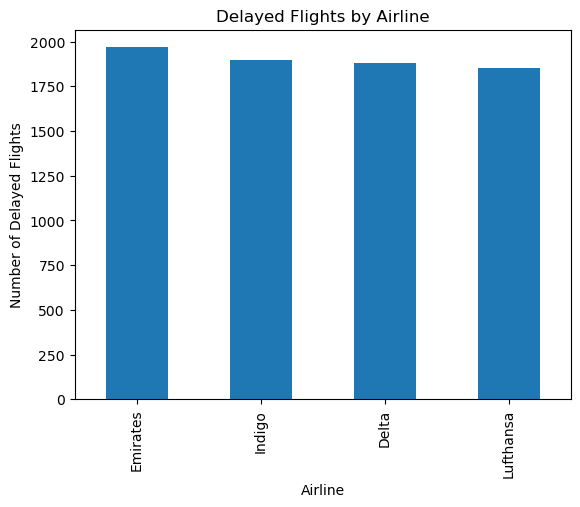

In [86]:
import matplotlib.pyplot as plt

df[df["Delay_Status"]=="Delayed"]["Airline"].value_counts().plot(kind="bar")

plt.title("Delayed Flights by Airline")
plt.ylabel("Number of Delayed Flights")

plt.show()

In [ ]:
---Does Distance Affect Delays?

In [89]:
df.groupby("Distance_Category")["Arrival_Delay_min"].mean()

Distance_Category
Long Haul       98.630714
Medium Long     99.321919
Short Haul     100.972474
Name: Arrival_Delay_min, dtype: float64

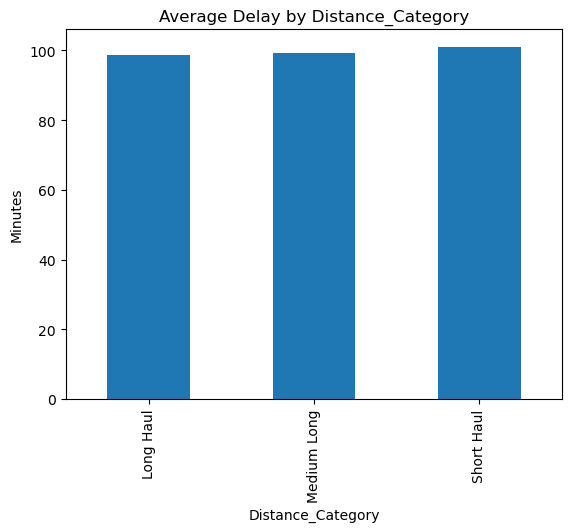

In [91]:
import matplotlib.pyplot as plt

df.groupby("Distance_Category")["Arrival_Delay_min"].mean().plot(kind="bar")

plt.title("Average Delay by Distance_Category")
plt.ylabel("Minutes")
plt.show()

In [ ]:
---Which Flights Recovered Delay?

In [93]:
recovered = df[df["Delay_Difference"] < 0]
recovered.head()

,Flight_ID,Airline,Distance_km,Departure_Delay_min,Arrival_Delay_min,Delay_Status,Delay_Difference,Distance_Category,Performance_Label
1,2,Emirates,11735,148,65,Delayed,-83,Long Haul,Poor
2,3,Delta,3555,176,72,Delayed,-104,Medium Long,Poor
4,5,Emirates,11483,150,76,OnTime,-74,Long Haul,Poor
11,12,Emirates,7635,144,46,OnTime,-98,Long Haul,Poor
13,14,Indigo,6910,139,49,OnTime,-90,Medium Long,Poor


In [98]:
recovered[["Flight_ID",
           "Airline",
           "Departure_Delay_min",
           "Arrival_Delay_min",
           "Delay_Difference"]]

,Flight_ID,Airline,Departure_Delay_min,Arrival_Delay_min,Delay_Difference
1,2,Emirates,148,65,-83
2,3,Delta,176,72,-104
4,5,Emirates,150,76,-74
11,12,Emirates,144,46,-98
13,14,Indigo,139,49,-90
...,...,...,...,...,...
14983,14984,Lufthansa,148,60,-88
14987,14988,Emirates,123,94,-29
14991,14992,Delta,73,58,-15
14995,14996,Emirates,143,83,-60


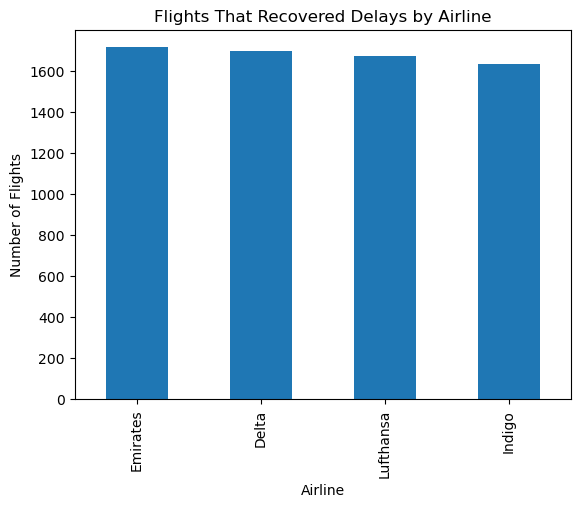

In [104]:
import matplotlib.pyplot as plt

recovered["Airline"].value_counts().plot(kind="bar")

plt.title("Flights That Recovered Delays by Airline")
plt.ylabel("Number of Flights")
plt.xlabel("Airline")

plt.show()

In [ ]:
---Which Flights Are Operationaly Inefficient 

In [105]:
inefficient = df[df["Arrival_Delay_min"] > 120]

inefficient.head()

,Flight_ID,Airline,Distance_km,Departure_Delay_min,Arrival_Delay_min,Delay_Status,Delay_Difference,Distance_Category,Performance_Label
0,1,Indigo,7609,4,155,Delayed,151,Long Haul,Poor
3,4,Indigo,7539,25,154,OnTime,129,Long Haul,Poor
5,6,Emirates,5961,81,153,Delayed,72,Medium Long,Poor
9,10,Delta,3778,92,144,OnTime,52,Medium Long,Poor
10,11,Delta,1317,99,152,OnTime,53,Short Haul,Poor


In [106]:
inefficient[["Flight_ID",
           "Airline",
           "Departure_Delay_min",
           "Arrival_Delay_min",
           "Delay_Difference"]]

,Flight_ID,Airline,Departure_Delay_min,Arrival_Delay_min,Delay_Difference
0,1,Indigo,4,155,151
3,4,Indigo,25,154,129
5,6,Emirates,81,153,72
9,10,Delta,92,144,52
10,11,Delta,99,152,53
...,...,...,...,...,...
14986,14987,Delta,145,184,39
14988,14989,Lufthansa,153,191,38
14989,14990,Lufthansa,29,195,166
14992,14993,Lufthansa,28,154,126


In [ ]:
---What Is The Average Delay Across All Flights?

In [107]:
df["Arrival_Delay_min"].mean()

np.float64(99.41233333333334)